# 05 — Platform & step-free access
**AccessMap London** · TfL Station Accessibility Gap Analysis

**Goal:** Analyse step-free platform coverage, level access by line, and step-free interchange distances.


## Setup — imports
*Run this first every time.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COLOURS = {
    'Good (70-100)':   '#1D9E75',
    'Partial (40-69)': '#EF9F27',
    'Poor (0-39)':     '#E24B4A',
}
BAND_ORDER = ['Good (70-100)', 'Partial (40-69)', 'Poor (0-39)']
PALETTE    = [COLOURS[b] for b in BAND_ORDER]

print('Libraries loaded ✓')

Libraries loaded ✓


## Load raw data
*Reads directly from `raw_data/` — no pre-processing.*

In [2]:
RAW = '../raw_data/'

stations     = pd.read_csv(RAW + 'Stations.csv')
lifts        = pd.read_csv(RAW + 'Lifts.csv')
platforms    = pd.read_csv(RAW + 'Platforms.csv')
platform_svc = pd.read_csv(RAW + 'PlatformServices.csv')
toilets      = pd.read_csv(RAW + 'Toilets.csv')
stn_points   = pd.read_csv(RAW + 'StationPoints.csv')
step_free    = pd.read_csv(RAW + 'StepFreeIntechangeInfo.csv')
ramp_routes  = pd.read_csv(RAW + 'RampRoutes.csv')
modes_lines  = pd.read_csv(RAW + 'ModesAndLines.csv')
feed_info    = pd.read_csv(RAW + 'FeedInfo.csv')

print('All raw files loaded ✓')
print(f'  Stations        : {len(stations):>4} rows')
print(f'  Lifts           : {len(lifts):>4} rows')
print(f'  Platforms       : {len(platforms):>4} rows')
print(f'  PlatformServices: {len(platform_svc):>4} rows')
print(f'  Toilets         : {len(toilets):>4} rows')
print(f'  StationPoints   : {len(stn_points):>4} rows')
print(f'  StepFreeInfo    : {len(step_free):>4} rows')
print(f'  RampRoutes      : {len(ramp_routes):>4} rows')

All raw files loaded ✓
  Stations        :  509 rows
  Lifts           :  569 rows
  Platforms       : 1584 rows
  PlatformServices: 1878 rows
  Toilets         :  410 rows
  StationPoints   : 4084 rows
  StepFreeInfo    :  114 rows
  RampRoutes      :  418 rows


## Clean data
*Fix boolean types, extract primary zone, normalise fields.*

In [3]:
def to_bool(s):
    return (s.astype(str).str.strip().str.upper()
             .map({'TRUE': True, 'FALSE': False, '1': True, '0': False, 'NAN': False})
             .fillna(False))

# Stations
st = stations.copy()
for col in ['Wifi','BlueBadgeCarParking','TaxiRanksOutsideStation',
            'MainBusInterchange','NationalRailInterchange','AirportInterchange']:
    if col in st.columns:
        st[col] = to_bool(st[col])
st['PrimaryZone'] = st['FareZones'].astype(str).str.extract(r'(\d)')[0].fillna('Unknown')

# Lifts
lf = lifts.copy()
lf['LimitedCapacityLift'] = to_bool(lf['LimitedCapacityLift'])

# Platforms
pl = platforms.copy()
pl['HasStepFreeRouteInformation'] = to_bool(pl['HasStepFreeRouteInformation'])

# PlatformServices
ps = platform_svc.copy()
ps['DesignatedLevelAccessPoint'] = to_bool(ps['DesignatedLevelAccessPoint'])
ps['LevelAccessByManualRamp']    = to_bool(ps['LevelAccessByManualRamp'])

# Toilets
tl = toilets.copy()
for col in ['IsAccessible','HasBabyChanging','IsInsideGateLine','IsFeeCharged','IsManagedByTfL']:
    tl[col] = to_bool(tl[col])

# Step-free — extract station prefix
sf = step_free.copy()
sf['FromStation'] = sf['FromPlatformUniqueId'].str.extract(r'^([^-]+-[^-]+)')

# Geo coords
geo = (stn_points.groupby('StationUniqueId')
                  .agg(Lat=('Lat','mean'), Lon=('Lon','mean'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))

print('Cleaning done ✓')

Cleaning done ✓


## Feature engineering
*Aggregate per station and compute the accessibility score.*

In [4]:
# Lift counts per station
lift_agg = (lf.groupby('StationUniqueId')
              .agg(TotalLifts=('LiftUniqueId','count'),
                   LimitedCapacityLifts=('LimitedCapacityLift','sum'))
              .reset_index())

# Step-free platforms per station
plat_agg = (pl.groupby('StationUniqueId')
              .agg(TotalPlatforms=('UniqueId','count'),
                   PlatformsWithStepFree=('HasStepFreeRouteInformation','sum'))
              .reset_index())
plat_agg['StepFreePlatformPct'] = (plat_agg['PlatformsWithStepFree'] / plat_agg['TotalPlatforms']).round(3)

# Step-free interchange per station
sf_agg = (sf.groupby('FromStation')
            .agg(AvgInterchangeDistM=('DistanceInMetres','mean'),
                 MaxInterchangeDistM=('DistanceInMetres','max'),
                 StepFreeInterchangeCount=('FromPlatformUniqueId','count'))
            .reset_index()
            .rename(columns={'FromStation':'UniqueId'}))

# Toilet counts per station
toilet_agg = (tl.groupby('StationUniqueId')
                .agg(TotalToilets=('Id','count'),
                     AccessibleToilets=('IsAccessible','sum'),
                     HasBabyChanging=('HasBabyChanging','any'),
                     FreeToilets=('IsFeeCharged', lambda x: (~x).sum()))
                .reset_index()
                .rename(columns={'StationUniqueId':'UniqueId'}))

# Level access per station
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')
ps_agg   = (ps_st.groupby('StationUniqueId')
                  .agg(TotalPlatformSvc=('PlatformUniqueId','count'),
                       LevelAccessPlatforms=('DesignatedLevelAccessPoint','sum'),
                       RampAccessPlatforms=('LevelAccessByManualRamp','sum'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))
ps_agg['LevelAccessPct'] = (ps_agg['LevelAccessPlatforms'] / ps_agg['TotalPlatformSvc']).round(3)

# Lines served per station
lines_agg = (ps_st.groupby('StationUniqueId')['Line']
                   .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
                   .reset_index()
                   .rename(columns={'StationUniqueId':'UniqueId','Line':'LinesServed'}))

# Ramp routes per station
rr = ramp_routes.copy()
rr['StationId'] = rr['From'].str.extract(r'^([^-]+-[^-]+)')
ramp_agg = (rr.groupby('StationId').size()
              .reset_index(name='RampRouteCount')
              .rename(columns={'StationId':'UniqueId'}))

# Assemble master table
master = st.copy()
for right, rkey, lkey in [
    (lift_agg,   'StationUniqueId', 'UniqueId'),
    (plat_agg,   'StationUniqueId', 'UniqueId'),
    (sf_agg,     'UniqueId',        'UniqueId'),
    (toilet_agg, 'UniqueId',        'UniqueId'),
    (ps_agg,     'UniqueId',        'UniqueId'),
    (lines_agg,  'UniqueId',        'UniqueId'),
    (ramp_agg,   'UniqueId',        'UniqueId'),
    (geo,        'UniqueId',        'UniqueId'),
]:
    master = master.merge(right, left_on=lkey, right_on=rkey, how='left')
    if rkey != lkey and rkey in master.columns:
        master.drop(columns=[rkey], inplace=True, errors='ignore')

# Fill missing
count_cols = ['TotalLifts','LimitedCapacityLifts','TotalPlatforms','PlatformsWithStepFree',
              'TotalToilets','AccessibleToilets','FreeToilets','TotalPlatformSvc',
              'LevelAccessPlatforms','RampAccessPlatforms','RampRouteCount','StepFreeInterchangeCount']
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)
for col in ['StepFreePlatformPct','LevelAccessPct']:
    if col in master.columns:
        master[col] = master[col].fillna(0)

# Accessibility score (0–100)
master['HasLift']             = (master['TotalLifts'] > 0).astype(int)
master['HasAccessibleToilet'] = (master['AccessibleToilets'] > 0).astype(int)
master['HasRamp']             = (master['RampRouteCount'] > 0).astype(int)

master['AccessibilityScore'] = (
    master['HasLift']             * 30 +
    master['StepFreePlatformPct'] * 25 +
    master['HasAccessibleToilet'] * 20 +
    master['LevelAccessPct']      * 15 +
    master['HasRamp']             * 10
).round(1)

master['AccessibilityBand'] = master['AccessibilityScore'].apply(
    lambda s: 'Good (70-100)' if s >= 70 else ('Partial (40-69)' if s >= 40 else 'Poor (0-39)')
)

print(f'Master table ready: {master.shape}')
print(master['AccessibilityBand'].value_counts())

Master table ready: (509, 40)
AccessibilityBand
Poor (0-39)        247
Partial (40-69)    172
Good (70-100)       90
Name: count, dtype: int64


---
## Platform & step-free access

In [5]:
# ── Step-free platform coverage overview ─────────────────────────
sf_cov = master[master['StepFreePlatformPct'] > 0]
print(f'Stations with any step-free platform info : {len(sf_cov)} ({len(sf_cov)/len(master)*100:.0f}%)')
print(f'Stations with 100% step-free platforms    : {(master["StepFreePlatformPct"]==1).sum()}')
print()
print('StepFreePlatformPct distribution:')
print(master['StepFreePlatformPct'].describe())

Stations with any step-free platform info : 481 (94%)
Stations with 100% step-free platforms    : 465

StepFreePlatformPct distribution:
count    509.000000
mean       0.929792
std        0.242207
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: StepFreePlatformPct, dtype: float64


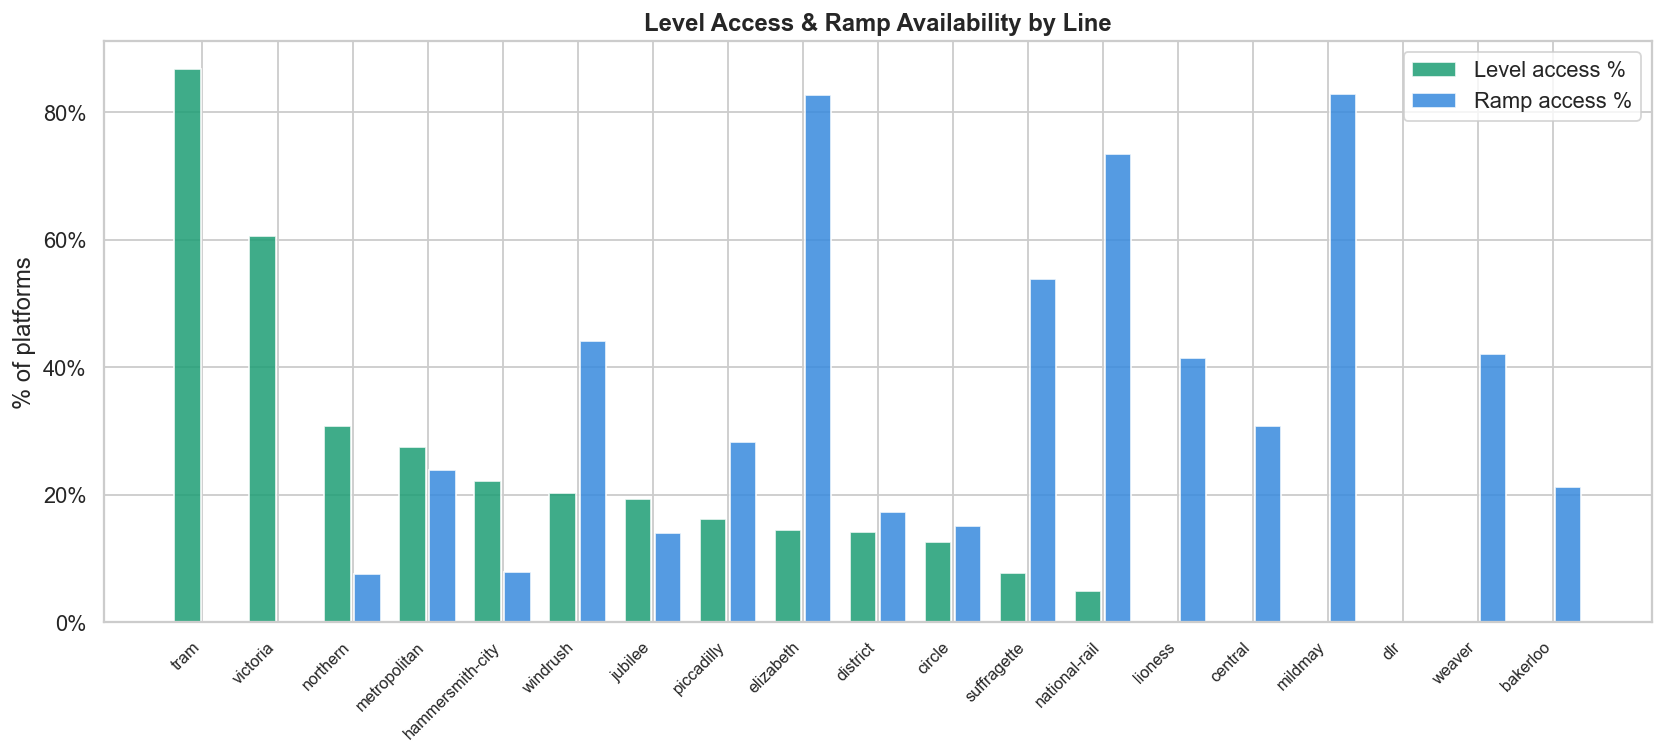

,Line,TotalPlatforms,LevelAccess,RampAccess,LevelPct,RampPct
0,tram,68,59,0,86.8,0.0
1,victoria,33,20,0,60.6,0.0
2,northern,120,37,9,30.8,7.5
3,metropolitan,84,23,20,27.4,23.8
4,hammersmith-city,63,14,5,22.2,7.9
5,windrush,59,12,26,20.3,44.1
6,jubilee,57,11,8,19.3,14.0
7,piccadilly,117,19,33,16.2,28.2
8,elizabeth,139,20,115,14.4,82.7
9,district,134,19,23,14.2,17.2


In [6]:
# ── Level access & ramp availability by line ─────────────────────
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')

ps_line = (ps_st.groupby('Line')
               .agg(TotalPlatforms=('PlatformUniqueId','count'),
                    LevelAccess=('DesignatedLevelAccessPoint','sum'),
                    RampAccess=('LevelAccessByManualRamp','sum'))
               .reset_index())
ps_line['LevelPct'] = (ps_line['LevelAccess'] / ps_line['TotalPlatforms'] * 100).round(1)
ps_line['RampPct']  = (ps_line['RampAccess']  / ps_line['TotalPlatforms'] * 100).round(1)
ps_line = ps_line[ps_line['TotalPlatforms'] >= 5].sort_values('LevelPct', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = range(len(ps_line))
ax.bar([i-0.2 for i in x], ps_line['LevelPct'], 0.35,
       label='Level access %', color='#1D9E75', alpha=0.85)
ax.bar([i+0.2 for i in x], ps_line['RampPct'],  0.35,
       label='Ramp access %',  color='#378ADD', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(ps_line['Line'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('% of platforms')
ax.set_title('Level Access & Ramp Availability by Line', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

display(ps_line.reset_index(drop=True))

Stations with step-free interchange data : 0
Average interchange distance             : nan m
Maximum interchange distance             : nan m


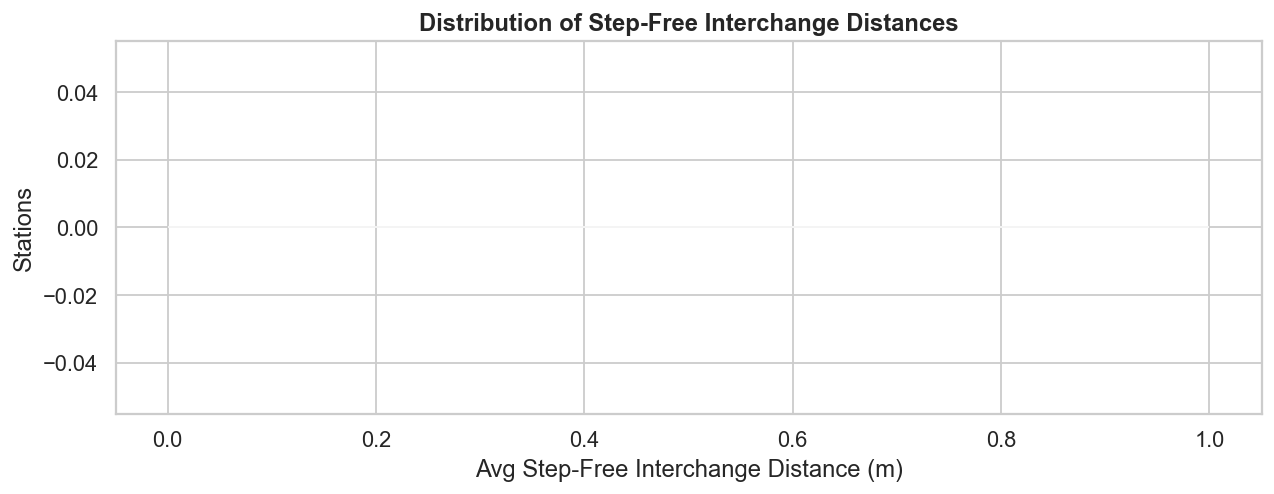


Longest step-free interchanges:


,Name,FareZones,MaxInterchangeDistM,AvgInterchangeDistM,AccessibilityScore
0,Abbey Wood,4,NaN,NaN,75.0
1,Acton Central,3,NaN,NaN,25.0
2,Acton Main Line,3,NaN,NaN,75.0
3,Anerley,4,NaN,NaN,25.0
4,Beckenham Hill,4,NaN,NaN,0.0
5,Bellingham,3,NaN,NaN,0.0
6,Bush Hill Park,5,NaN,NaN,45.0
7,Bickley,5,NaN,NaN,0.0
8,Burnham,Outside,NaN,NaN,75.0
9,Brondesbury,2,NaN,NaN,25.0


In [7]:
# ── Step-free interchange distances ──────────────────────────────
print(f'Stations with step-free interchange data : {(master["StepFreeInterchangeCount"]>0).sum()}')
print(f'Average interchange distance             : {master["AvgInterchangeDistM"].dropna().mean():.0f} m')
print(f'Maximum interchange distance             : {master["MaxInterchangeDistM"].dropna().max():.0f} m')

sf_dist = master[master['AvgInterchangeDistM'].notna()]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sf_dist['AvgInterchangeDistM'], bins=20,
        color='#378ADD', edgecolor='white', alpha=0.85)
ax.set_xlabel('Avg Step-Free Interchange Distance (m)')
ax.set_ylabel('Stations')
ax.set_title('Distribution of Step-Free Interchange Distances', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nLongest step-free interchanges:')
display(master.nlargest(10, 'MaxInterchangeDistM')
        [['Name','FareZones','MaxInterchangeDistM','AvgInterchangeDistM','AccessibilityScore']]
        .reset_index(drop=True))